# [LAB11] 지도학습 > 시계열 분석 > Prophet (BaseModel)

Facebook(현 Meta)에서 개발한 시계열 예측 라이브러리  
https://facebook.github.io/prophet/  
https://peerj.com/preprints/3190.pdf

## 📘 #01. 라이브러리 개요

### 📝 [1] Prophet의 목적
- 시간에 따른 데이터의 추세(Trend) 파악
- 반복되는 계절성(Seasonality) 분석
- 공휴일·이벤트 효과 반영
- 미래 값 예측

### 📝 [2] Prophet의 특징
- 결측치에 비교적 강함
- 불규칙한 간격 데이터 처리 가능
- 자동으로 추세 변화점(changepoint) 탐지
- 연/월/주 단위 계절성 자동 처리
- 파라미터 튜닝이 비교적 단순함

### 📝 [3] Prophet이 적합한 경우
- 매출 예측
- 방문자 수 예측
- 거래량 예측
- 트렌드 + 계절성이 존재하는 데이터

## 📘 #02. 준비작업

### 📝 [1] 패키지 참조

In [36]:
!pip install hossam

  Using cached imbalanced_learn-0.13.0-py3-none-any.whl.metadata (8.8 kB)
Using cached imbalanced_learn-0.13.0-py3-none-any.whl (238 kB)
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.1
    Uninstalling imbalanced-learn-0.14.1:
      Successfully uninstalled imbalanced-learn-0.14.1


In [24]:
from hossam import *
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
from pandas import to_datetime, DataFrame
from prophet import Prophet
from prophet.plot import add_changepoints_to_plot
from sklearn.metrics import mean_absolute_error, mean_squared_error

### 📝 [2] 데이터 가져오기

In [25]:
origin = load_data("air_passengers")
origin.head()

어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)

| Month | Passengers |
|-------|------------|
| 1949-01-01 | 112 |
| 1949-02-01 | 118 |
| ... | ... |

In [26]:
df_prophet = origin.rename(columns={'Month': 'ds', 'Passengers': 'y'})
df_prophet['ds'] = to_datetime(df_prophet['ds'])
df_prophet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      144 non-null    datetime64[ns]
 1   y       144 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.4 KB


## 📘 #03. 시계열 데이터 준비

### 📝 [1] 데이터 분할

- **(1) 단순 비율 분할** (예: 80%/20%)
- **(2) 날짜 기준 분할** (예: 특정 시점 이후를 검증)

In [27]:
# 분할 비율
split_ratio = 0.8
# 분할 인덱스
split_idx = int(len(df_prophet) * split_ratio)
# 훈련 / 검증 데이터
train = df_prophet.iloc[:split_idx]
test = df_prophet.iloc[split_idx:]
print("Train 기간:", train['ds'].min(), "~", train['ds'].max())
print("Valid 기간:", test['ds'].min(), "~", test['ds'].max())

Train 기간: 1949-01-01 00:00:00 ~ 1958-07-01 00:00:00
Valid 기간: 1958-08-01 00:00:00 ~ 1960-12-01 00:00:00


In [28]:
# 검증 시작일 설정
split_date = "1958-08-01"
train = df_prophet[df_prophet['ds'] < split_date]
test = df_prophet[df_prophet['ds'] >= split_date]
print("Train 기간:", train['ds'].min(), "~", train['ds'].max())
print("Valid 기간:", test['ds'].min(), "~", test['ds'].max())

Train 기간: 1949-01-01 00:00:00 ~ 1958-07-01 00:00:00
Valid 기간: 1958-08-01 00:00:00 ~ 1960-12-01 00:00:00


### 📝 [2] 공휴일 데이터 설정

공휴일 효과를 기대할 수 없다면 이 과정은 생략할 수 있다.

**Air Passengers Dataset의 특성**  
- 기간: 1949-01 ~ 1960-12  
- 빈도: 월간(Monthly)  
- 지역: 미국 항공 수요로 간주  

**1950년대 미국 항공 수요에 영향을 주는 대표 시즌**  
| 시즌 | 월 | 근거 |
|------|-----|------|
| Independence Day | 7월 | 여름 휴가 성수기 |
| Thanksgiving | 11월 | 대규모 이동 |
| Christmas | 12월 | 연말 이동 |
| Summer Vacation | 6~8월 | 계절적 항공 수요 증가 |

**공휴일 효과**: Prophet의 공휴일 효과는 하루짜리 충격(impulse)이 아니라 지정한 범위까지 영향이 확장되는 구조임.  
- `lower_window`: 공휴일 **이전** 며칠까지 효과를 줄 것인지  
- `upper_window`: 공휴일 **이후** 며칠까지 효과를 줄 것인지  

월간 데이터에서는 1개월이 최소 단위이므로 `lower_window=0`, `upper_window=0`로 두고, 월 전체 영향은 해당 월 첫날로 통일.

In [29]:
# 전체 연도 범위
years = range(1949, 1961)
holiday_list = []
for y in years:
    holiday_list.extend([
        # Independence Day → 7월 효과
        {'holiday': 'independence_day', 'ds': f'{y}-07-01'},
        # Thanksgiving → 11월 효과
        {'holiday': 'thanksgiving', 'ds': f'{y}-11-01'},
        # Christmas → 12월 효과
        {'holiday': 'christmas', 'ds': f'{y}-12-01'},
        # Summer Vacation 시작 → 6월
        {'holiday': 'summer_vacation', 'ds': f'{y}-06-01'}
    ])

holidays = DataFrame(holiday_list)
holidays['ds'] = to_datetime(holidays['ds'])
# 공휴일 효과 없음으로 설정 (월간 데이터이므로)
holidays['lower_window'] = 0
holidays['upper_window'] = 0
holidays.head()

,holiday,ds,lower_window,upper_window
0,independence_day,1949-07-01,0,0
1,thanksgiving,1949-11-01,0,0
2,christmas,1949-12-01,0,0
3,summer_vacation,1949-06-01,0,0
4,independence_day,1950-07-01,0,0


## 📘 #03. 시계열 학습 모델 구현

### 📝 [1] 기본 모형 설정

| 파라미터 | 권장값 | 의미 |
|----------|--------|------|
| growth | 'linear' | 데이터가 시간에 따라 일정하게 증가/감소 |
| changepoint_prior_scale | 0.05 | 추세 변화점 허용 정도 |
| seasonality_mode | 'additive' | 계절 효과가 일정한 크기로 반복 |
| yearly_seasonality | True | 1년 주기 반복 패턴 학습 |
| weekly_seasonality | False | 월간 데이터이므로 False |
| daily_seasonality | False | 월간 데이터이므로 False |

**데이터 주기별 추천**:  
- 월간: yearly=True, weekly=False, daily=False  
- 일별: yearly=True, weekly=True, daily=False  
- 시간 단위: yearly=True, weekly=True, daily=True

In [30]:
model = Prophet(
    growth='linear',
    changepoint_prior_scale=0.05,
    seasonality_mode='additive',
    yearly_seasonality=True,
    weekly_seasonality=False,  # 월간 데이터이므로 False
    daily_seasonality=False,
    holidays=holidays,
    seasonality_prior_scale=10,
    holidays_prior_scale=10
)
model.fit(train)

12:23:44 - cmdstanpy - INFO - Chain [1] start processing
12:23:44 - cmdstanpy - INFO - Chain [1] done processing


### 📝 [2] 학습결과를 활용하여 예측

`periods`는 예측할 기간 (일(D), 월(M) 단위 설정 가능 / 기본은 일단위)

### 📝 [3] 예측 결과에 대한 시각화

- **모델 적합 확인 (Train 구간)**: 검은 점과 파란 선이 잘 겹치면 적합 양호. 큰 편차가 지속되면 언더피팅 가능.
- **일반화 확인 (Test 구간)**: 검은 점선(test)이 파란 선과 가깝다면 예측 성능 양호. 지속적으로 위/아래로 벗어나면 편향 발생.

| 시각 요소 | 의미 |
|-----------|------|
| Observed (검은 점) | 실제 학습 데이터 |
| Forecast yhat (파란 실선) | 모델 예측값 |
| Uncertainty interval (반투명 영역) | 신뢰 구간 |
| Test(real) (주황 점선) | 검증 데이터 실제값 |

In [31]:
future = model.make_future_dataframe(periods=len(test), freq='M')
forecast = model.predict(future)
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,christmas,christmas_lower,christmas_upper,holidays,holidays_lower,holidays_upper,independence_day,independence_day_lower,independence_day_upper,summer_vacation,summer_vacation_lower,summer_vacation_upper,thanksgiving,thanksgiving_lower,thanksgiving_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1949-01-01,109.622,68.959,113.436,109.622,109.622,-19.512,-19.512,-19.512,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-19.512,-19.512,-19.512,0.000,0.000,0.000,90.110
1,1949-02-01,111.756,62.718,106.648,111.756,111.756,-27.885,-27.885,-27.885,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-27.885,-27.885,-27.885,0.000,0.000,0.000,83.870
2,1949-03-01,113.682,96.898,139.286,113.682,113.682,4.279,4.279,4.279,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,4.279,4.279,4.279,0.000,0.000,0.000,117.961
3,1949-04-01,115.816,86.816,131.110,115.816,115.816,-5.550,-5.550,-5.550,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-5.550,-5.550,-5.550,0.000,0.000,0.000,110.266
4,1949-05-01,117.880,88.992,133.627,117.880,117.880,-6.688,-6.688,-6.688,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-6.688,-6.688,-6.688,0.000,0.000,0.000,111.193


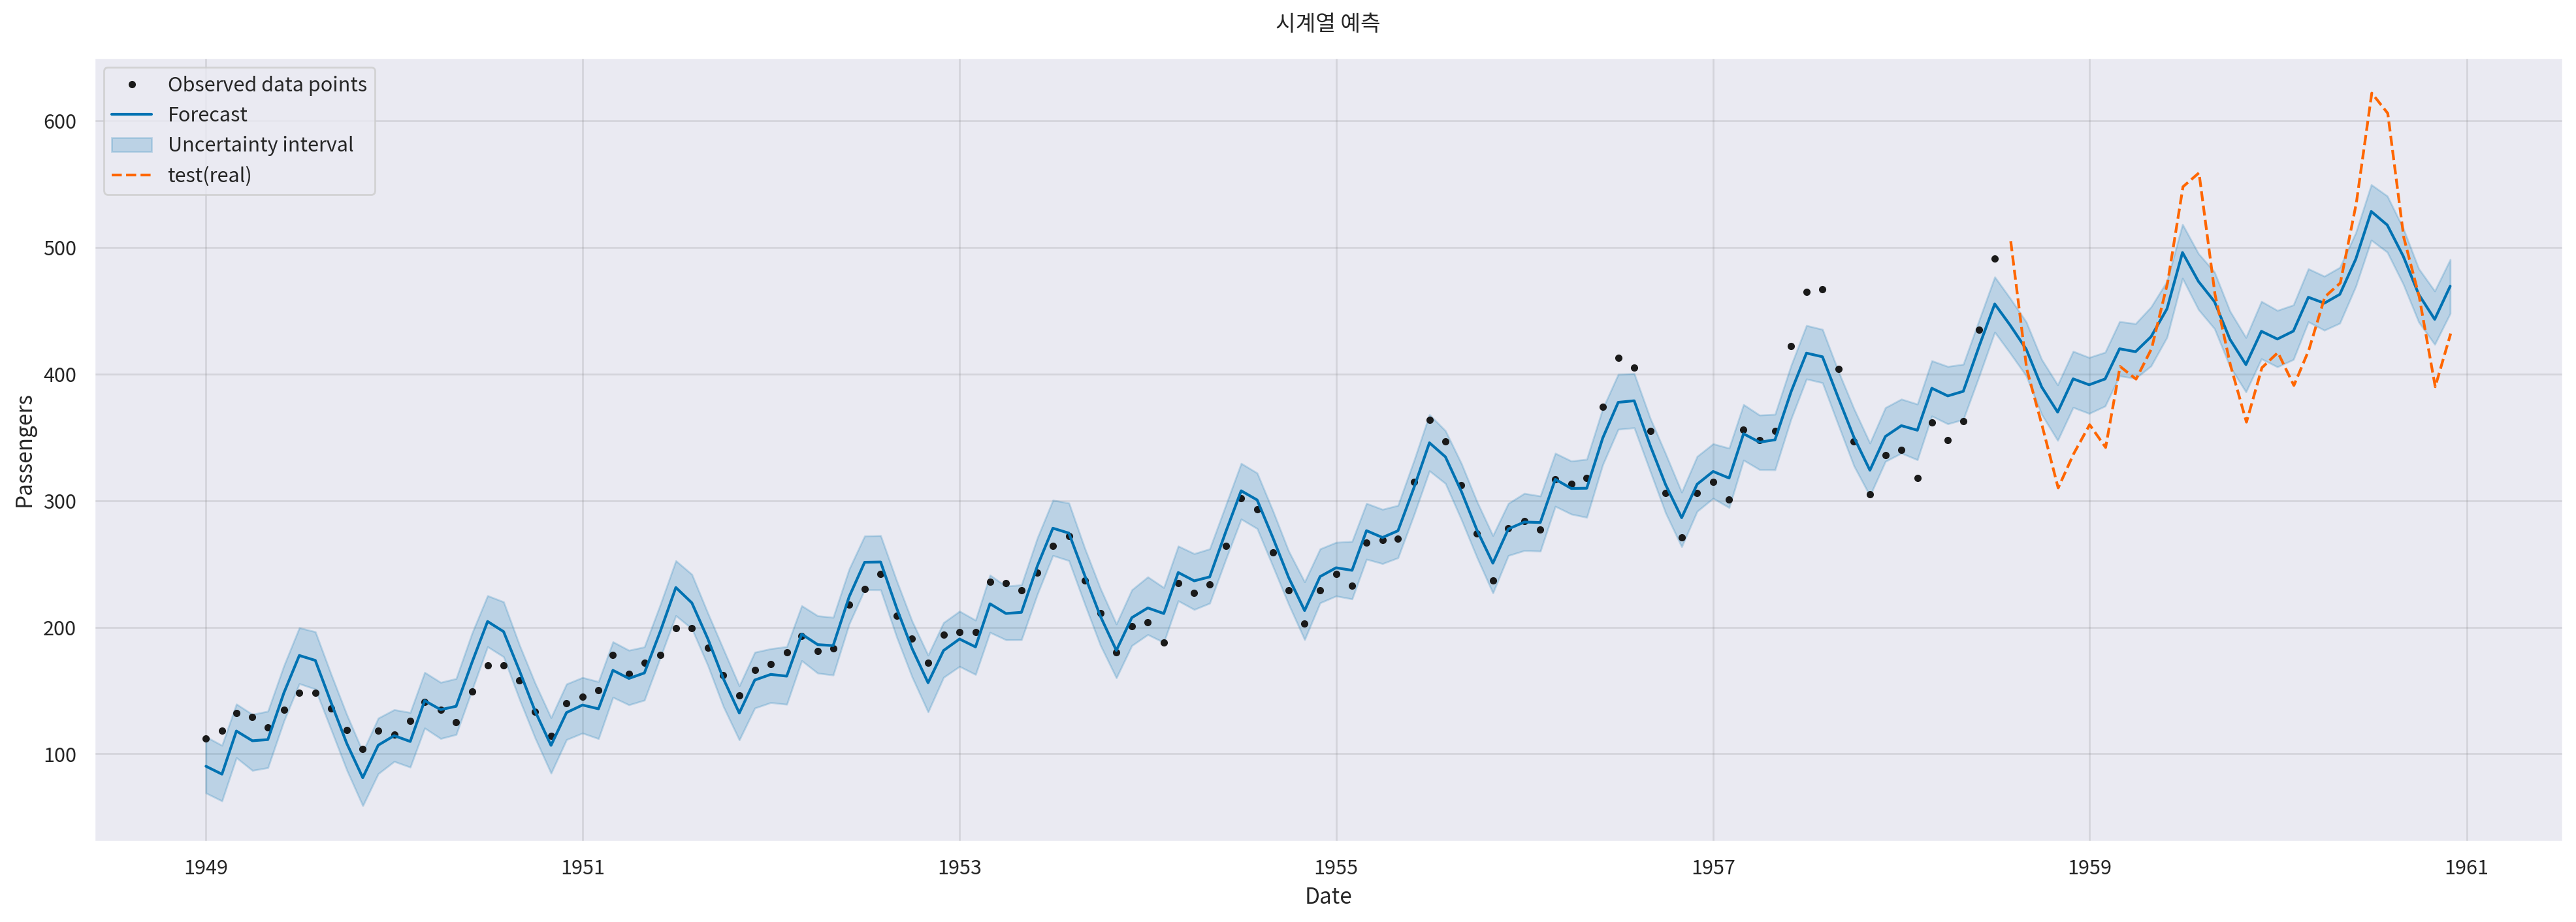

In [32]:
fig = model.plot(forecast, figsize=(20, 7), xlabel='Date', ylabel='Passengers', uncertainty=True)
ax = fig.gca()
ax.set_title("시계열 예측")
# 실제 검증 데이터는 직접 추가한다.
sb.lineplot(data=test, x='ds', y='y', ax=ax, color='#ff6600', linestyle="--", label='test(real)')
plt.show()
plt.close()

### 📝 [4] changepoint를 추가한 시각화

**changepoint**: Trend가 변화하는 지점  
- `fig.gca()`: 시계열 그래프의 axes  
- `add_changepoints_to_plot(ax, model, forecast)`: 추세 변화점 표시

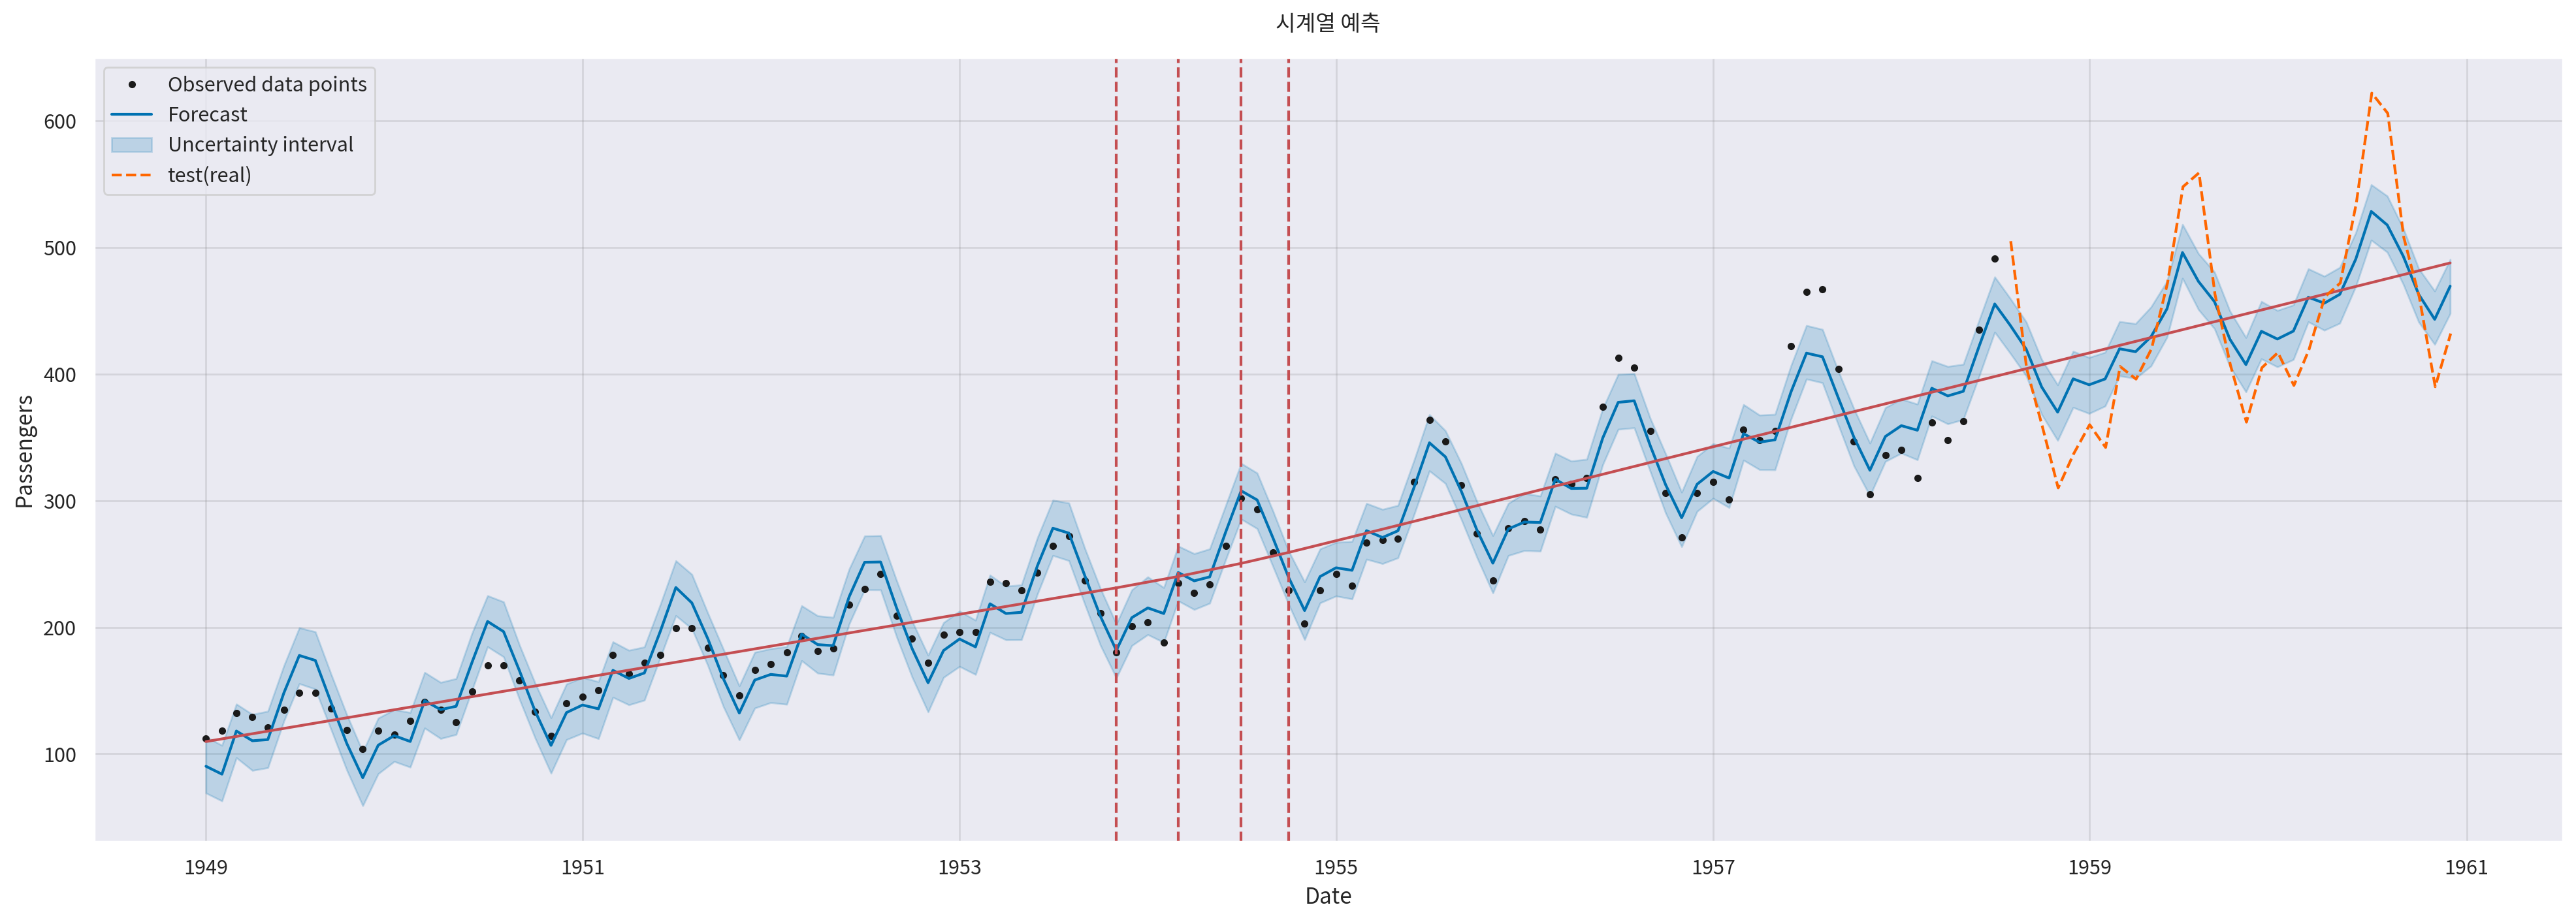

In [33]:
fig = model.plot(forecast, figsize=(20, 7), xlabel='Date', ylabel='Passengers', uncertainty=True)
ax = fig.gca()
add_changepoints_to_plot(ax, model, forecast)
ax.set_title("시계열 예측")
sb.lineplot(data=test, x='ds', y='y', ax=ax, color='#ff6600', linestyle="--", label='test(real)')
plt.show()
plt.close()

### 📝 [5] 모델이 갖는 컴포넌트 확인 (성분분해)

`model.plot_components(forecast)`: trend, yearly seasonality 등 분해

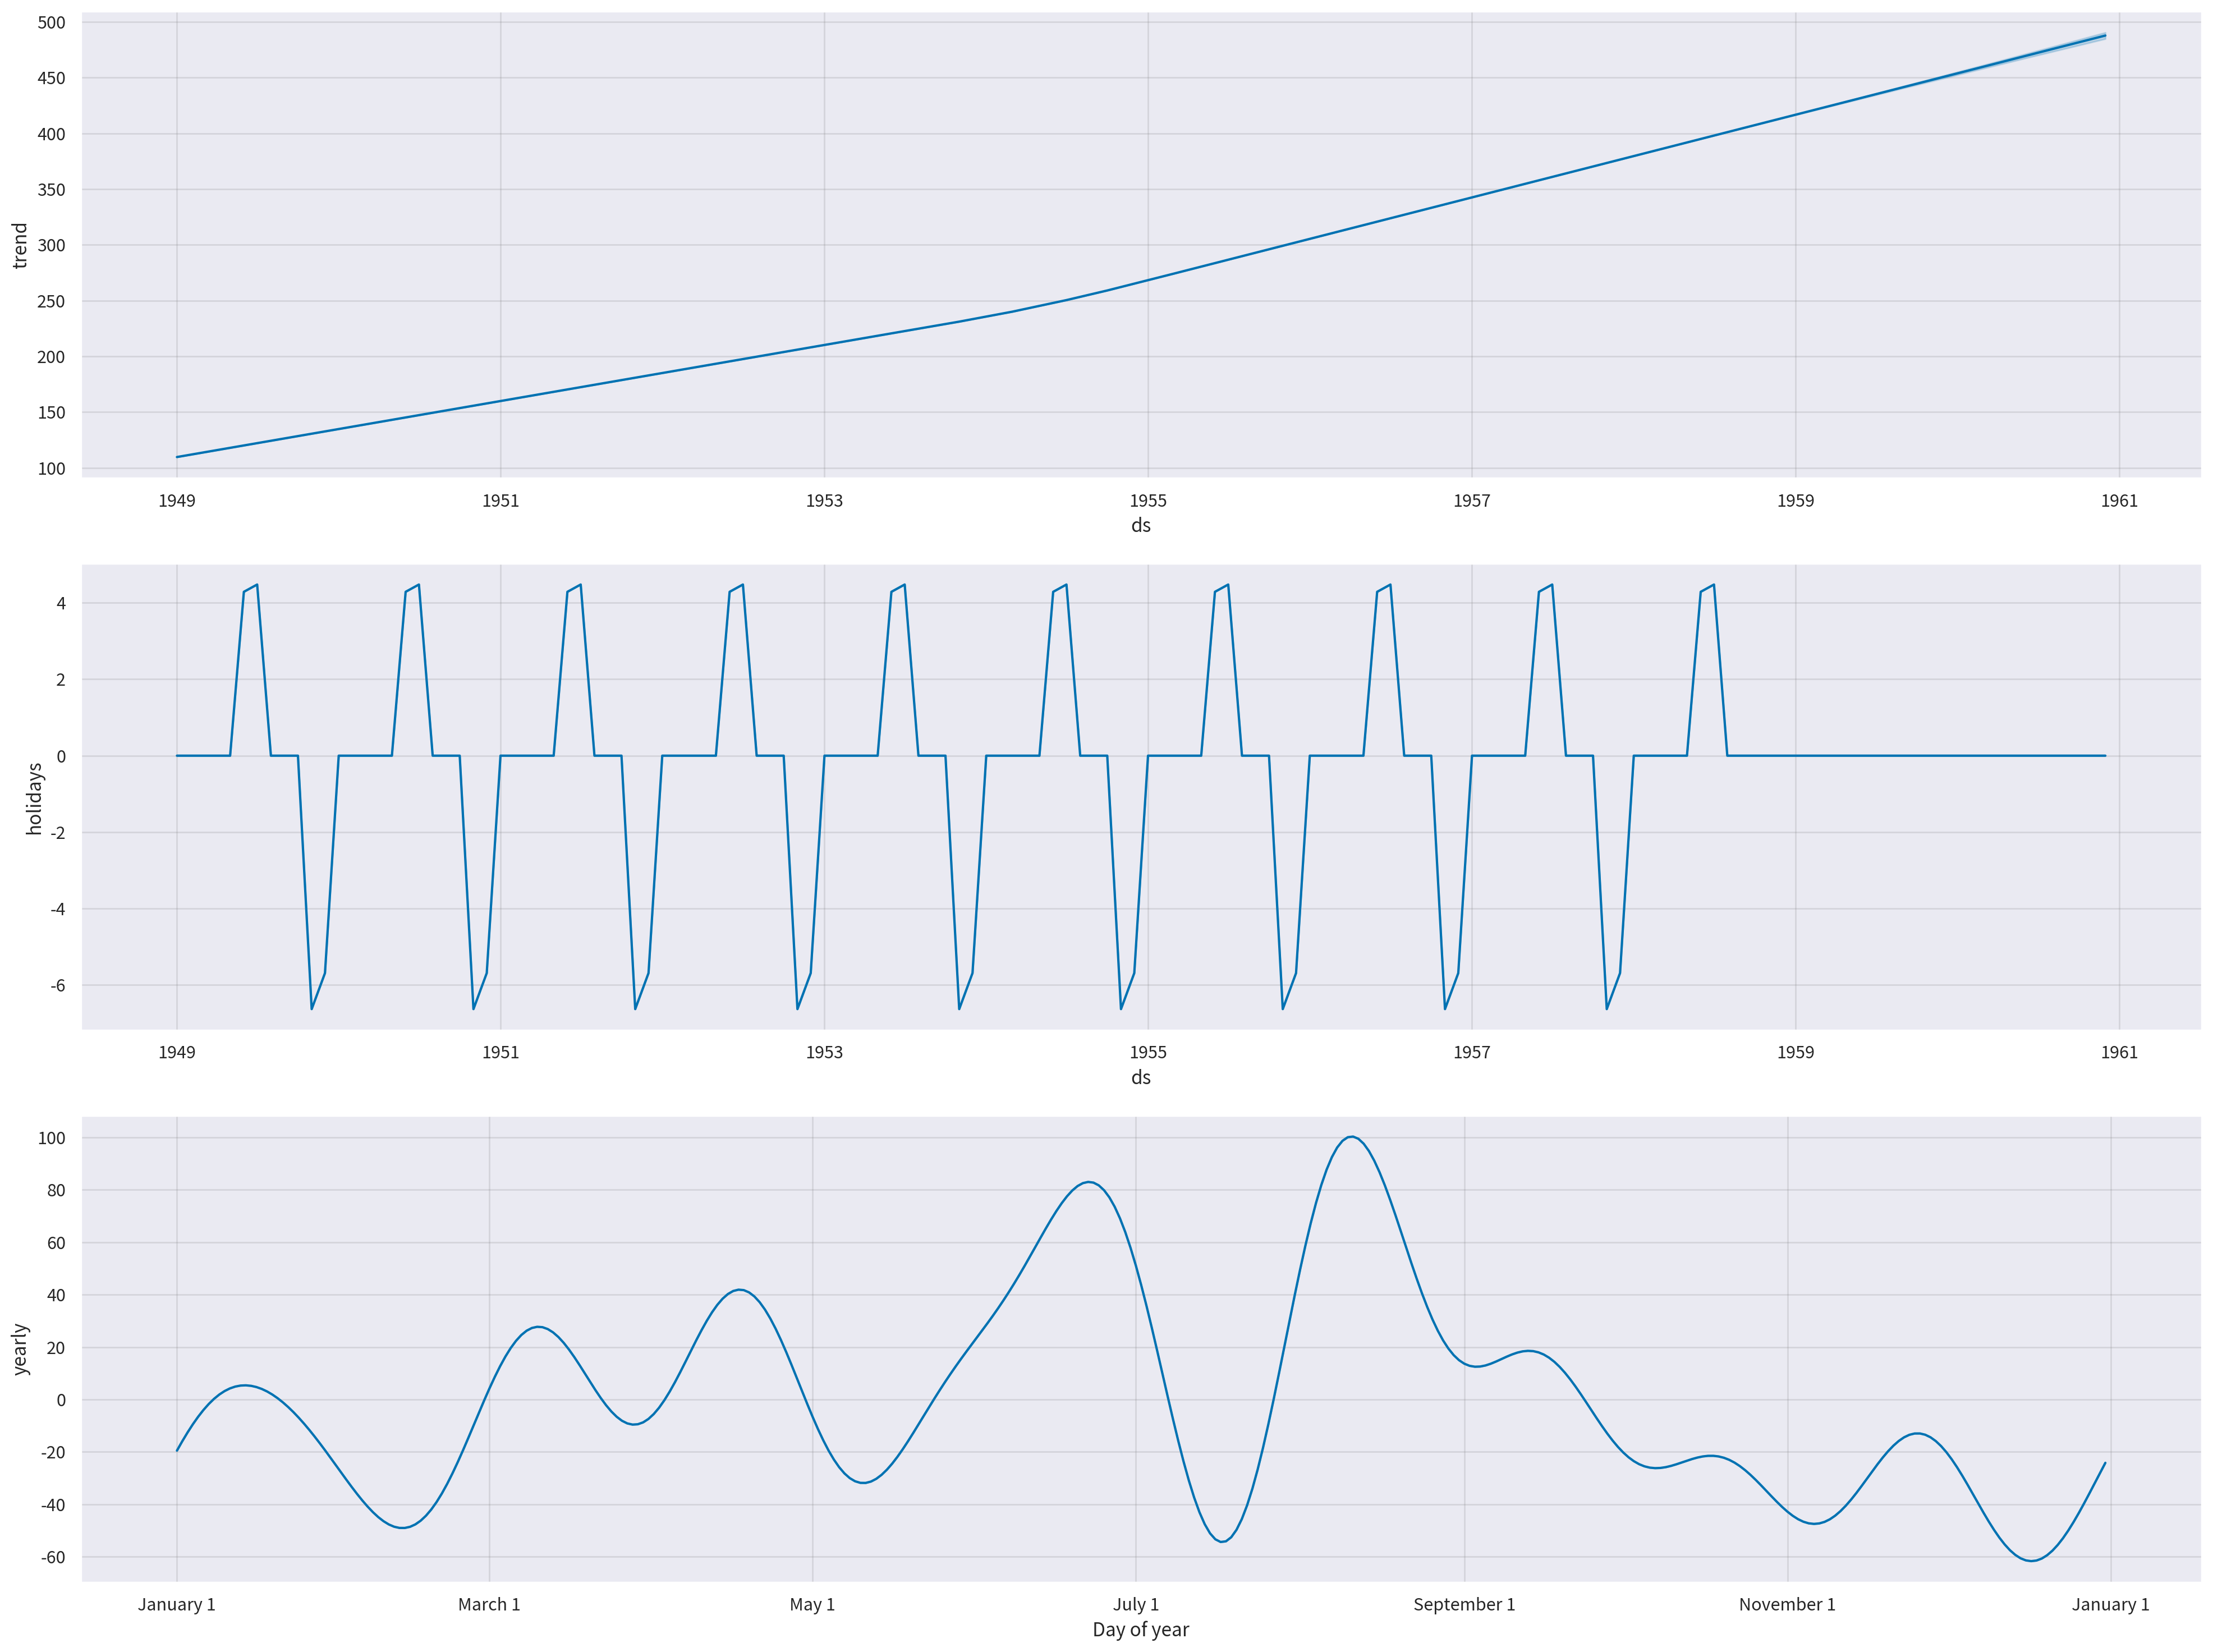

In [34]:
fig = model.plot_components(forecast, figsize=(20, 15))
plt.show()
plt.close()

## 📘 #04. 성능평가

### 📝 실제 y값과 예측 y값 얻기
### 📝 Test(Validation) 성능 계산
### 📝 Train 성능 계산
### 📝 과적합 판단

| 조건 | 해석 |
|------|------|
| Valid RMSE ≈ Train RMSE | 일반화 양호 |
| Valid RMSE > Train RMSE (차이 큼) | 과적합 의심 |
| 둘 다 큼 | 언더피팅 가능 |

시계열에서는 "과거 패턴을 지나치게 세밀하게 따라간 결과 미래 예측이 불안정해지는 현상"이 과적합에 해당하며, 예측 방향성·신뢰구간 안정성·구조 일관성으로 해석하는 것이 실무적.

In [35]:
y = test['y'].values
yhat = forecast['yhat'].values[-len(test):]

valid_mae = mean_absolute_error(y, yhat)
valid_mse = mean_squared_error(y, yhat)
valid_rmse = np.sqrt(valid_mse)

# train 구간 예측값 추출
yhat_train = forecast['yhat'].values[:-len(test)]
y_train = train['y'].values
train_mae = mean_absolute_error(y_train, yhat_train)
train_mse = mean_squared_error(y_train, yhat_train)
train_rmse = np.sqrt(train_mse)

rmse_gap = valid_rmse - train_rmse
gap_ratio = rmse_gap / train_rmse
if gap_ratio > 0.2:
    overfit_flag = "과적합 의심"
elif gap_ratio > 0.1:
    overfit_flag = "약한 과적합 가능성"
else:
    overfit_flag = "일반화 양호"

result = DataFrame({
    "Train_MAE": [train_mae],
    "Train_RMSE": [train_rmse],
    "Valid_MAE": [valid_mae],
    "Valid_RMSE": [valid_rmse],
    "RMSE_차이": [rmse_gap],
    "차이비율": [gap_ratio],
    "과적합의심여부": [overfit_flag]
})
result

,Train_MAE,Train_RMSE,Valid_MAE,Valid_RMSE,RMSE_차이,차이비율,과적합의심여부
0,13.164,16.928,36.699,44.707,27.779,1.641,과적합 의심
